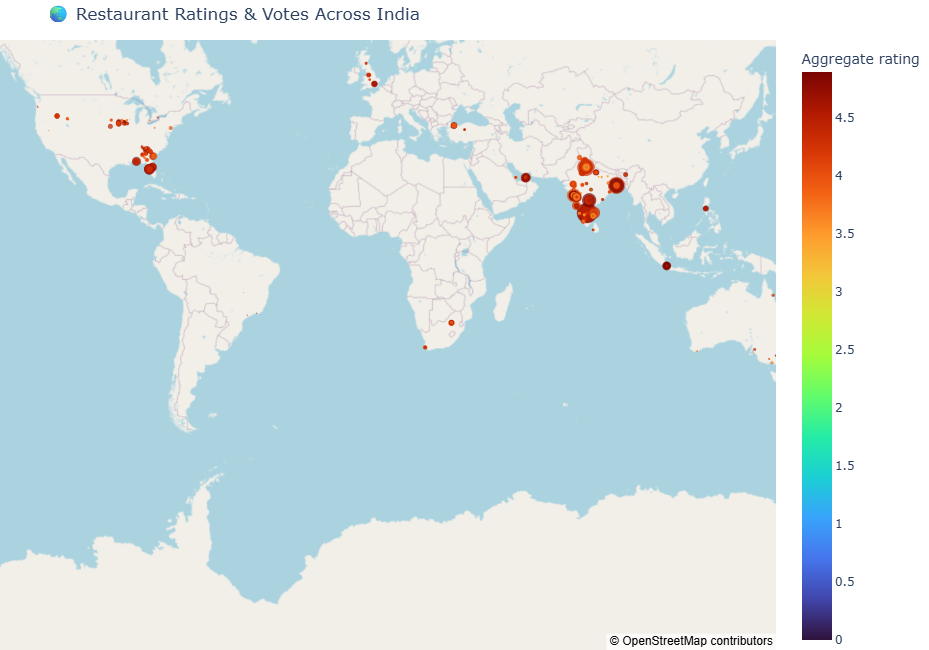

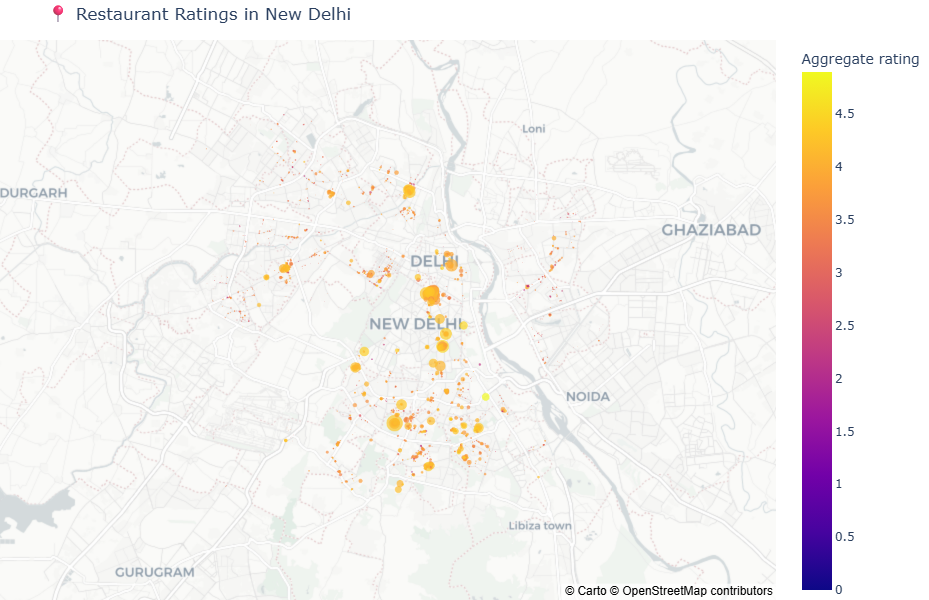

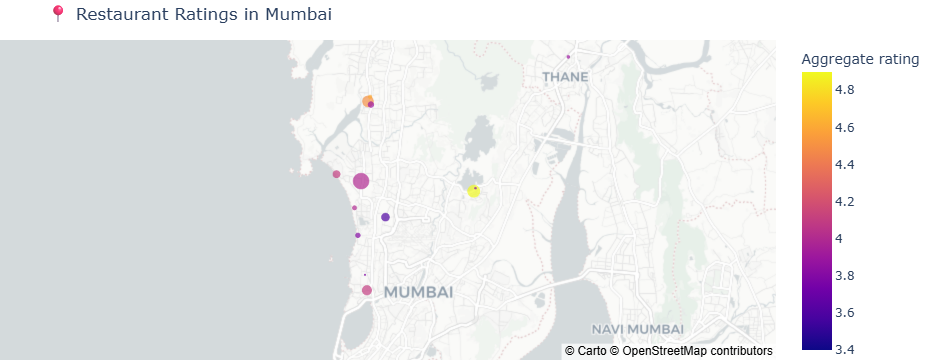

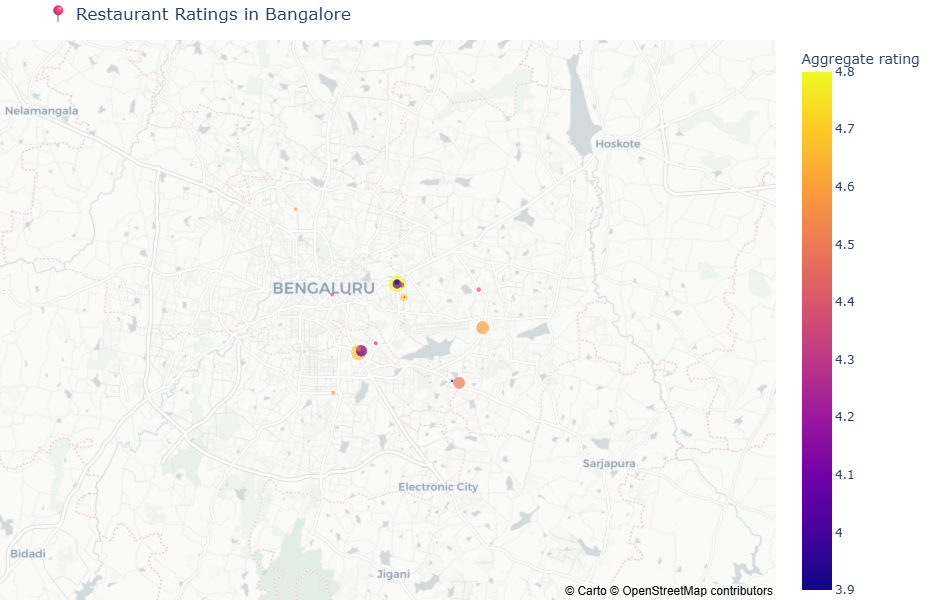

🏙️ Top 10 Restaurant Clusters by City:

        City  Restaurant Count
0  New Delhi              5240
1    Gurgaon              1070
2      Noida               986
3  Faridabad               229
4  Ghaziabad                25
5  Ahmedabad                21
6      Dubai                20
7    Sharjah                20
8   Pretoria                20
9  Abu Dhabi                20


In [2]:
# 📦 Import Required Libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 📥 Load Dataset
df = pd.read_csv(r"C:\Users\acer\Downloads\Data Analysis Internship__Dataset__Cognifyz Technologies.csv") 

# 🧹 Clean: Drop missing or invalid coordinates
geo_df = df[['Restaurant Name', 'City', 'Latitude', 'Longitude', 'Aggregate rating', 'Votes']].dropna()
geo_df = geo_df[(geo_df['Latitude'] != 0.0) & (geo_df['Longitude'] != 0.0)]

# ------------------------------------------
# 🌍 MAP 1: National-Level Interactive Map
# ------------------------------------------
fig_national = px.scatter_mapbox(
    geo_df,
    lat="Latitude",
    lon="Longitude",
    hover_name="Restaurant Name",
    hover_data={
        "City": True,
        "Aggregate rating": True,
        "Votes": True
    },
    color="Aggregate rating",
    size="Votes",
    size_max=15,
    color_continuous_scale="Turbo",
    zoom=4,
    title="🌏 Restaurant Ratings & Votes Across India"
)
fig_national.update_layout(mapbox_style="open-street-map", margin={"r":0, "t":40, "l":0, "b":0}, height=650)
fig_national.show()

# ------------------------------------------
# 📍 MAP 2: City Zooms (Delhi, Mumbai, Bangalore)
# ------------------------------------------
major_cities = ['New Delhi', 'Mumbai', 'Bangalore']

for city in major_cities:
    city_df = geo_df[geo_df['City'] == city]

    fig = px.scatter_mapbox(
        city_df,
        lat="Latitude",
        lon="Longitude",
        hover_name="Restaurant Name",
        hover_data={
            "Aggregate rating": True,
            "Votes": True
        },
        color="Aggregate rating",
        size="Votes",
        size_max=12,
        color_continuous_scale="Plasma",
        zoom=10,
        title=f"📍 Restaurant Ratings in {city}"
    )

    fig.update_layout(mapbox_style="carto-positron", margin={"r": 0, "t": 40, "l": 0, "b": 0}, height=600)
    fig.show()

# ------------------------------------------
# 🧠 OPTIONAL: City Clustering Summary
# ------------------------------------------
city_counts = geo_df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Restaurant Count']
top_cluster_cities = city_counts.head(10)

print("🏙️ Top 10 Restaurant Clusters by City:\n")
print(top_cluster_cities)
